# Tutorial 1: Visium (Triple Negative Breast Cancer)

This tutorial walks through a full **Renoir** workflow on a 10x Genomics **Visium** spatial transcriptomics dataset of **Triple-Negative Breast Cancer (TNBC)**. The original dataset comes from [Wu et al., *Nature Genetics* 2021](https://www.nature.com/articles/s41588-021-00911-1#data-availability).

Unlike single-cell platforms (e.g., CosMx), Visium captures gene expression at the **spot level** — each spot covers a small tissue area containing several cells. Renoir handles this by combining the spatial expression matrix (`ST`) with a matched scRNA-seq reference (`SC`) and per-spot cell-type proportions (typically from `cell2location` deconvolution).

By the end of this notebook you will have:

1. Computed **neighborhood communication scores** at the spot level.
2. Visualized **ligand–target activity** spatially across the tissue section.
3. Built **pathway-level** ligand–target clusters from MSigDB.
4. Identified **communication domains** via Leiden clustering on the score matrix.
5. Run **differential expression** between domains and a **ligand-ranking** analysis to find drivers of a domain of interest.

---

## Table of Contents

1. [Setup and imports](#1-setup-and-imports)
2. [Compute neighborhood scores](#2-compute-neighborhood-scores)
3. [Spatial visualization of a ligand–target pair](#3-spatial-visualization-of-a-ligandtarget-pair)
4. [Build pathway and de novo ligand–target clusters](#4-build-pathway-and-de-novo-ligandtarget-clusters)
5. [Identify communication domains](#5-identify-communication-domains)
6. [Visualize communication domains in space](#6-visualize-communication-domains-in-space)
7. [Differential expression between domains](#7-differential-expression-between-domains)
8. [Pathway activity in space](#8-pathway-activity-in-space)
9. [Ligand ranking analysis](#9-ligand-ranking-analysis)

---

> Data required to run this tutorial can be found here: https://zenodo.org/records/20078137.


## 1. Setup and imports


In [1]:
import Renoir
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import pickle
import matplotlib.pyplot as plt

# Make spatial plots a comfortable size by default
plt.rcParams['figure.figsize'] = [8, 8]


## 2. Compute neighborhood scores

`Renoir.compute_neighborhood_scores` is the core step of the pipeline. For every **spot** in the Visium slide, it builds a local neighborhood (default = adjacent Visium spots in the hexagonal grid) and computes a score for each **ligand → target gene** pair. The score is weighted by the expression of the ligand in neighboring spots, the receptor in the focal spot, and a regulatory-potential prior linking ligand to target.

### Key arguments

| Argument | What it is |
|---|---|
| `SC_path` | Path to the matched **scRNA-seq reference** AnnData. |
| `ST_path` | Path to the **spatial (Visium) AnnData**. |
| `pairs_path` | CSV of pre-selected top ligand–target pairs (here, top 10 ordered by joint optimization). |
| `ligand_receptor_path` | Curated ligand–receptor pair table (e.g., from NATMI / OmniPath). |
| `celltype_proportions_path` | Per-spot cell-type proportions from a deconvolution method like cell2location. |
| `expins_path` | Precomputed neighborhood-expression pickle — speeds things up substantially on Visium-scale data. |

> **Heads-up:** this step takes a few minutes. The pandas `FutureWarning` you'll see in the output below is harmless and comes from upstream pandas API deprecations.

> **Visium-specific note:** because Visium is spot-level, we don't pass `single_cell=True` (the default is `False`, matching this case). The neighborhood is the spot's hexagonal ring — no need to set a `radius`.


In [2]:
neighborhood_scores = Renoir.compute_neighborhood_scores(
    SC_path='/path/to/scRNA.h5ad',
    ST_path='/path/to/ST.h5ad',
    pairs_path='/path/to/top_10_target_opt_both_ordered.csv',
    ligand_receptor_path='/path/to/All_human_lrpairs.csv',
    celltype_proportions_path='/path/to/celltype_proportions.csv',
    expins_path='/path/to/mRNA_subset_new.pkl',
)


/home/nr57/.conda/envs/genomics/lib/python3.11/site-packages/Renoir/renoir.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_sc = mean_sc.groupby('celltype').mean().T.to_dict()
/home/nr57/.conda/envs/genomics/lib/python3.11/site-packages/Renoir/renoir.py:276: RuntimeWarning: divide by zero encountered in log10
  PEM = np.log10(expins/E)


## 3. Spatial visualization of a ligand–target pair

The simplest exploratory view is a spatial map of one ligand–target pair painted onto the tissue. Below we plot **`LAMB1:MYC`** — laminin subunit beta-1 driving MYC expression — across the slide.

> If a pair you care about isn't in the default top-10 set, you can either edit the ligand–target list passed to `compute_neighborhood_scores`, or rerun with a larger top-N file (e.g., `top_100_target_opt_both_ordered.csv`).


/tmp/ipykernel_3829508/802394492.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(neighborhood_scores, img_key="hires", color=["LAMB1:MYC"], size = 1.4, alpha_img=0)


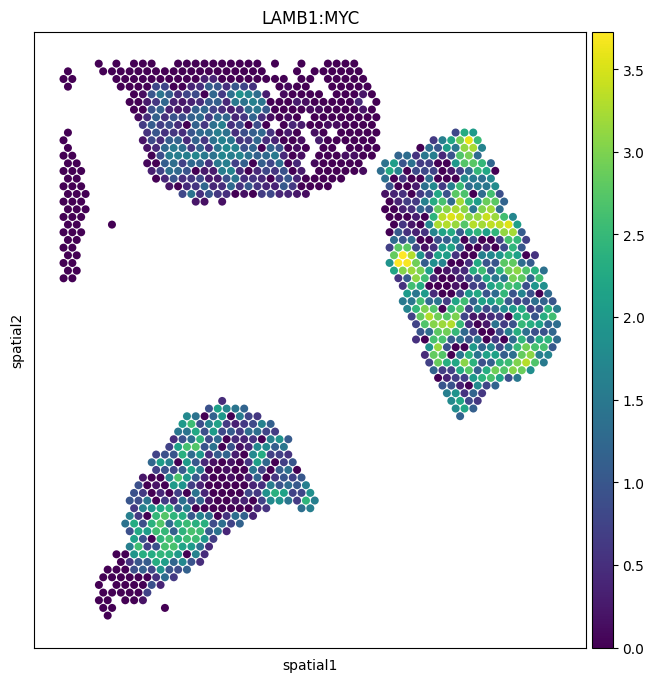

In [3]:
sc.pl.spatial(
    neighborhood_scores,
    img_key="hires",
    color=["LAMB1:MYC"],
    size=1.4,
    alpha_img=0,
)


## 4. Build pathway and de novo ligand–target clusters

Renoir lets you group ligand–target pairs into **clusters** so you can score whole biological programs at once. Two flavors are supported:

- **Pathway-based clusters** — using a curated gene-set database (e.g., MSigDB Hallmark, KEGG, WikiPathways). Each pathway becomes a cluster of all ligand–target pairs whose target gene is in that set.
- **De novo clusters** — discovered directly from the score matrix, with no prior knowledge required.

Below we use a custom MSigDB CSV combining Hallmark, KEGG, and WikiPathways human gene sets.

In [4]:
# Load curated MSigDB pathways (Hallmark + KEGG + WikiPathways, human)
msigh = Renoir.get_msig('custom', path='/path/to/msig_human_WP_H_KEGG_new.csv')

# Build one ligand-target cluster per pathway
pathways = Renoir.create_cluster(
    neighborhood_scores,
    msigh,
    method=None,          # pathway-based only; pass 'leiden' (etc.) to also get de novo clusters
    restrict_to_KHW=True, # keep only KEGG / Hallmark / WikiPathways
)

# Peek at the available pathway names
pathways.keys()


dict_keys(['HALLMARK_ALLOGRAFT_REJECTION', 'HALLMARK_APICAL_JUNCTION', 'HALLMARK_APOPTOSIS', 'HALLMARK_COAGULATION', 'HALLMARK_COMPLEMENT', 'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION', 'HALLMARK_ESTROGEN_RESPONSE_LATE', 'HALLMARK_HYPOXIA', 'HALLMARK_IL2_STAT5_SIGNALING', 'HALLMARK_IL6_JAK_STAT3_SIGNALING', 'HALLMARK_INFLAMMATORY_RESPONSE', 'HALLMARK_INTERFERON_GAMMA_RESPONSE', 'HALLMARK_KRAS_SIGNALING_UP', 'HALLMARK_TNFA_SIGNALING_VIA_NFKB', 'HALLMARK_UV_RESPONSE_UP', 'KEGG_ALLOGRAFT_REJECTION', 'KEGG_APOPTOSIS', 'KEGG_AUTOIMMUNE_THYROID_DISEASE', 'KEGG_BLADDER_CANCER', 'KEGG_CELL_ADHESION_MOLECULES_CAMS', 'KEGG_CHEMOKINE_SIGNALING_PATHWAY', 'KEGG_CYTOKINE_CYTOKINE_RECEPTOR_INTERACTION', 'KEGG_ERBB_SIGNALING_PATHWAY', 'KEGG_FOCAL_ADHESION', 'KEGG_GAP_JUNCTION', 'KEGG_GLIOMA', 'KEGG_GRAFT_VERSUS_HOST_DISEASE', 'KEGG_INTESTINAL_IMMUNE_NETWORK_FOR_IGA_PRODUCTION', 'KEGG_JAK_STAT_SIGNALING_PATHWAY', 'KEGG_LEUKOCYTE_TRANSENDOTHELIAL_MIGRATION', 'KEGG_MAPK_SIGNALING_PATHWAY', 'KEGG_MELANOMA

## 5. Identify communication domains

`downstream_analysis` returns:

- `neighbscore_copy` — a copy of the AnnData with `obs['leiden']` populated (one label per spot = its domain).
- `pcs` — an AnnData of per-pathway activity scores (used in section 8 below).

### Tuning knobs
- **`resolution=0.6`** — Leiden resolution. Lower → fewer, broader domains; higher → more, finer ones. Visium slides typically use a higher resolution than CosMx because spots are much sparser than single cells.
- **`n_markers=20`** / **`n_top=20`** — number of top marker pairs per cluster to retain for downstream interpretation.
- **`pdf_path=None`** — set to a filepath to dump diagnostic plots to PDF.


In [5]:
neighbscore_copy, pcs = Renoir.downstream_analysis(
    neighborhood_scores,
    ltpair_clusters=pathways,
    resolution=0.6,
    n_markers=20,
    n_top=20,
    pdf_path=None,
    return_cluster=True,
    return_pcs=True,
)


/home/nr57/.conda/envs/genomics/lib/python3.11/site-packages/Renoir/downstream.py:182: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pcs = pcs.applymap(abs)
/home/nr57/.conda/envs/genomics/lib/python3.11/site-packages/scipy/sparse/_index.py:145: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
/home/nr57/.conda/envs/genomics/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/nr57/.conda/envs/genomics/lib/python3.11/site-packages/Renoir/downstream.py:227: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to w

## 6. Visualize communication domains in space


/tmp/ipykernel_3829508/3103730653.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(neighbscore_copy, img_key="hires", color=["leiden"], size=1.4, alpha_img=0)


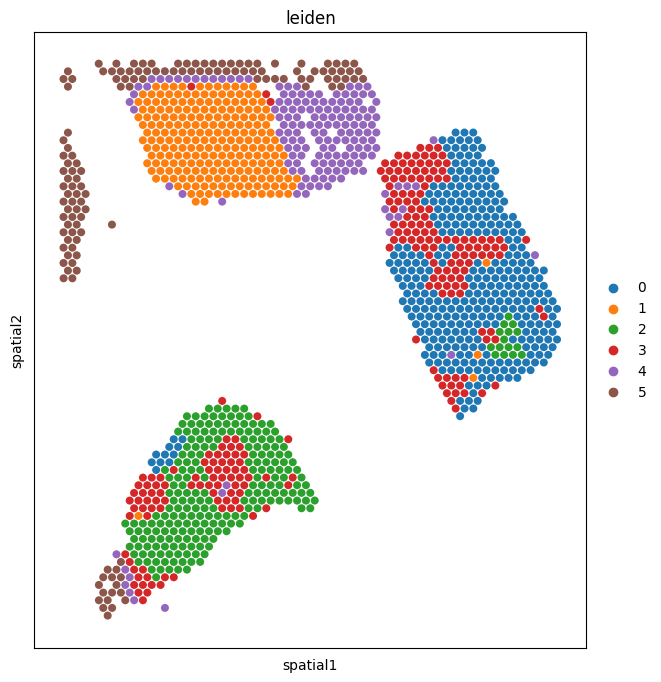

In [6]:
sc.pl.spatial(
    neighbscore_copy,
    img_key="hires",
    color=["leiden"],
    size=1.4,
    alpha_img=0,
)


## 7. Differential expression between domains

In [7]:
# Carry the domain labels back to the original score AnnData
neighborhood_scores.obs['leiden'] = neighbscore_copy.obs['leiden']
neighborhood_scores.uns = neighbscore_copy.uns


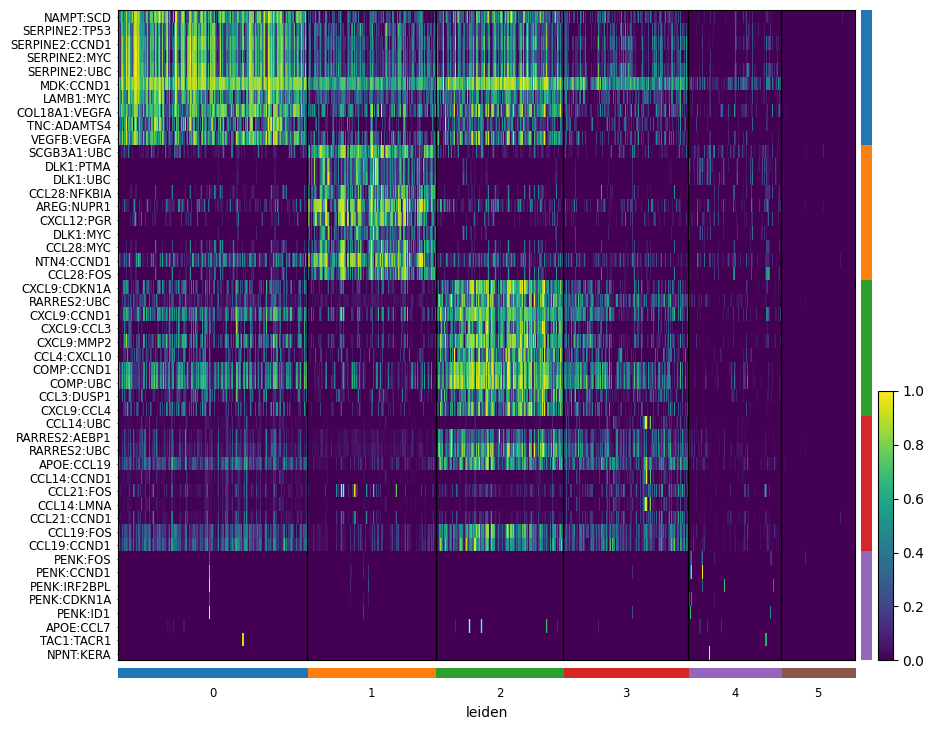

In [8]:
# One-vs-rest Wilcoxon ranking of ligand-target pairs per domain
sc.tl.rank_genes_groups(neighborhood_scores, "leiden", method="wilcoxon")

# Heatmap of the top-10 pairs per domain
sc.pl.rank_genes_groups_heatmap(
    neighborhood_scores,
    n_genes=10,
    groupby="leiden",
    show_gene_labels=True,
    min_logfoldchange=0.5,
    dendrogram=False,
    swap_axes=True,
    standard_scale='var',
    cmap='viridis',
)


## 8. Pathway activity in space

The `pcs` AnnData returned by `downstream_analysis` holds a **per-spot activity score for every pathway cluster**. Painting one of these onto the tissue is often more interpretable than a single ligand–target pair, because it summarizes a whole biological program.

Below we visualize `HALLMARK_IL6_JAK_STAT3_SIGNALING` — a canonical inflammatory pathway active in many tumors, including TNBC. Bright regions = areas where IL6/JAK/STAT3 signaling activity is predicted from the neighborhood.

/tmp/ipykernel_3829508/2273691165.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(pcs, img_key="hires", color=['HALLMARK_IL6_JAK_STAT3_SIGNALING'], size = 1.4, alpha_img=0, cmap='YlGnBu_r')


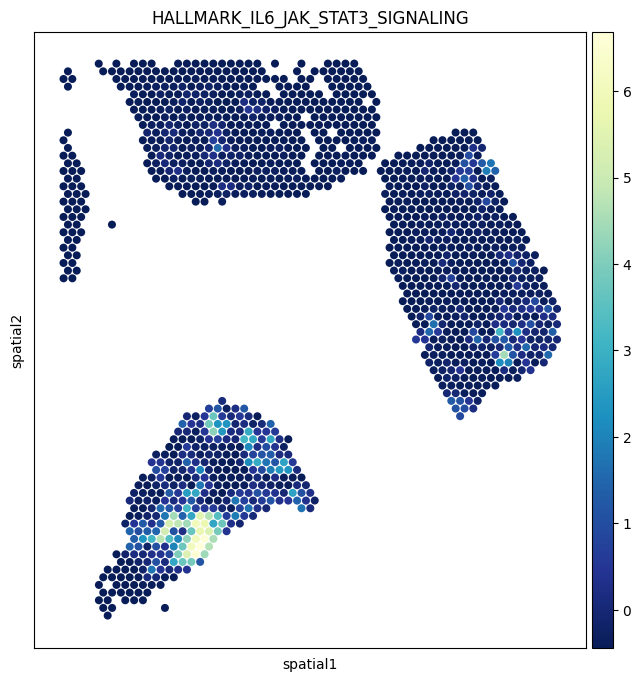

In [9]:
sc.pl.spatial(
    pcs,
    img_key="hires",
    color=['HALLMARK_IL6_JAK_STAT3_SIGNALING'],
    size=1.4,
    alpha_img=0,
    cmap='YlGnBu_r',
)


## 9. Ligand ranking analysis

Inputs needed:

- `celltype` — AnnData with cell-type proportions per spot (the cell2location output).
- `ligand_receptor_pairs` — curated L–R table (here, from NATMI).
- `ligand_target_regulatory_potential` — a precomputed pickle of ligand → top-500 target regulatory scores.
- `SC` — the matched scRNA-seq reference (used to measure receptor expression in each cell type).
- `celltype_colors` — a custom palette so cell types render with consistent, distinguishable colors across plots.

We also stash a copy of `neighborhood_scores` into `.raw` so the ranking function can recover the unmodified scores after the DE step above.


In [10]:
# Cell-type proportions per spot (from cell2location)
celltype = sc.read_h5ad('/path/to/celltype.h5ad')

# Curated NATMI ligand-receptor table
ligand_receptor_pairs = pd.read_csv('/path/to/NATMI_ligand_receptor_pairs.csv')

# Precomputed ligand -> top-500 target regulatory potentials
ligand_target_regulatory_potential = pickle.load(
    open('/path/to/top_500_target_opt_both_scores.pkl', 'rb')
)

# Custom palette so cell-type colors stay consistent across plots
celltype_colors = {
    'Cancer Basal SC':      '#4a6e45',
    'Cancer Cycling':       '#8727a8',
    'T cells CD4+':         '#f19bf6',
    'CAFs myCAF-like':      '#919225',
    'T cells CD8+':         '#861c1c',
    'PVL Differentiated':   '#cc9900',
    'CAFs MSC iCAF-like':   '#0099ff',
    'Luminal Progenitors':  '#b12a55',
    'Mature Luminal':       '#906e1f',
    'Myoepithelial':        '#a48cf4',
    'Endothelial ACKR1':    '#f45cf2',
    'Macrophage':           '#f66bad',
    'Plasmablasts':         '#ffff00',
}

# Matched scRNA-seq reference (used to measure receptor expression per cell type)
SC = sc.read_h5ad('/path/to/scRNA.h5ad')

# Stash the score matrix so ligand_ranking can reach the raw values
neighborhood_scores.raw = neighborhood_scores.copy()


### Run the ranking for domain `'0'`

The arguments below say:

- `'0'` — rank ligands for **communication domain 0** (change to whichever domain you're investigating).
- `receptor_exp=0.05` — keep only ligands whose **receptor is expressed in at least 5%** of spots in the domain. Filters out ligands the domain literally can't sense.
- `markers={'top': 100}` — use the top 100 marker ligand–target pairs of the domain to score each ligand.
- `domain_celltypes=['top', 5]` — restrict the analysis to the **top 5 cell types** by abundance in the domain.
- `celltype_colors=celltype_colors` — use the custom palette defined above.

The output is a multi-panel figure: ligand ranking, expressing cell types, and the spatial location of the domain. Repeat with different domain IDs (`'1'`, `'2'`, …) to characterize the entire tissue.


/home/nr57/.conda/envs/genomics/lib/python3.11/site-packages/Renoir/downstream.py:881: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.1448754370212555' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  ct_bar_plot.loc[row,col] = celltype_avg[domain][col]
/home/nr57/.conda/envs/genomics/lib/python3.11/site-packages/Renoir/downstream.py:881: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.0755910575389862' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  ct_bar_plot.loc[row,col] = celltype_avg[domain][col]
/home/nr57/.conda/envs/genomics/lib/python3.11/site-packages/Renoir/downstream.py:881: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.04784858226776123' has dty

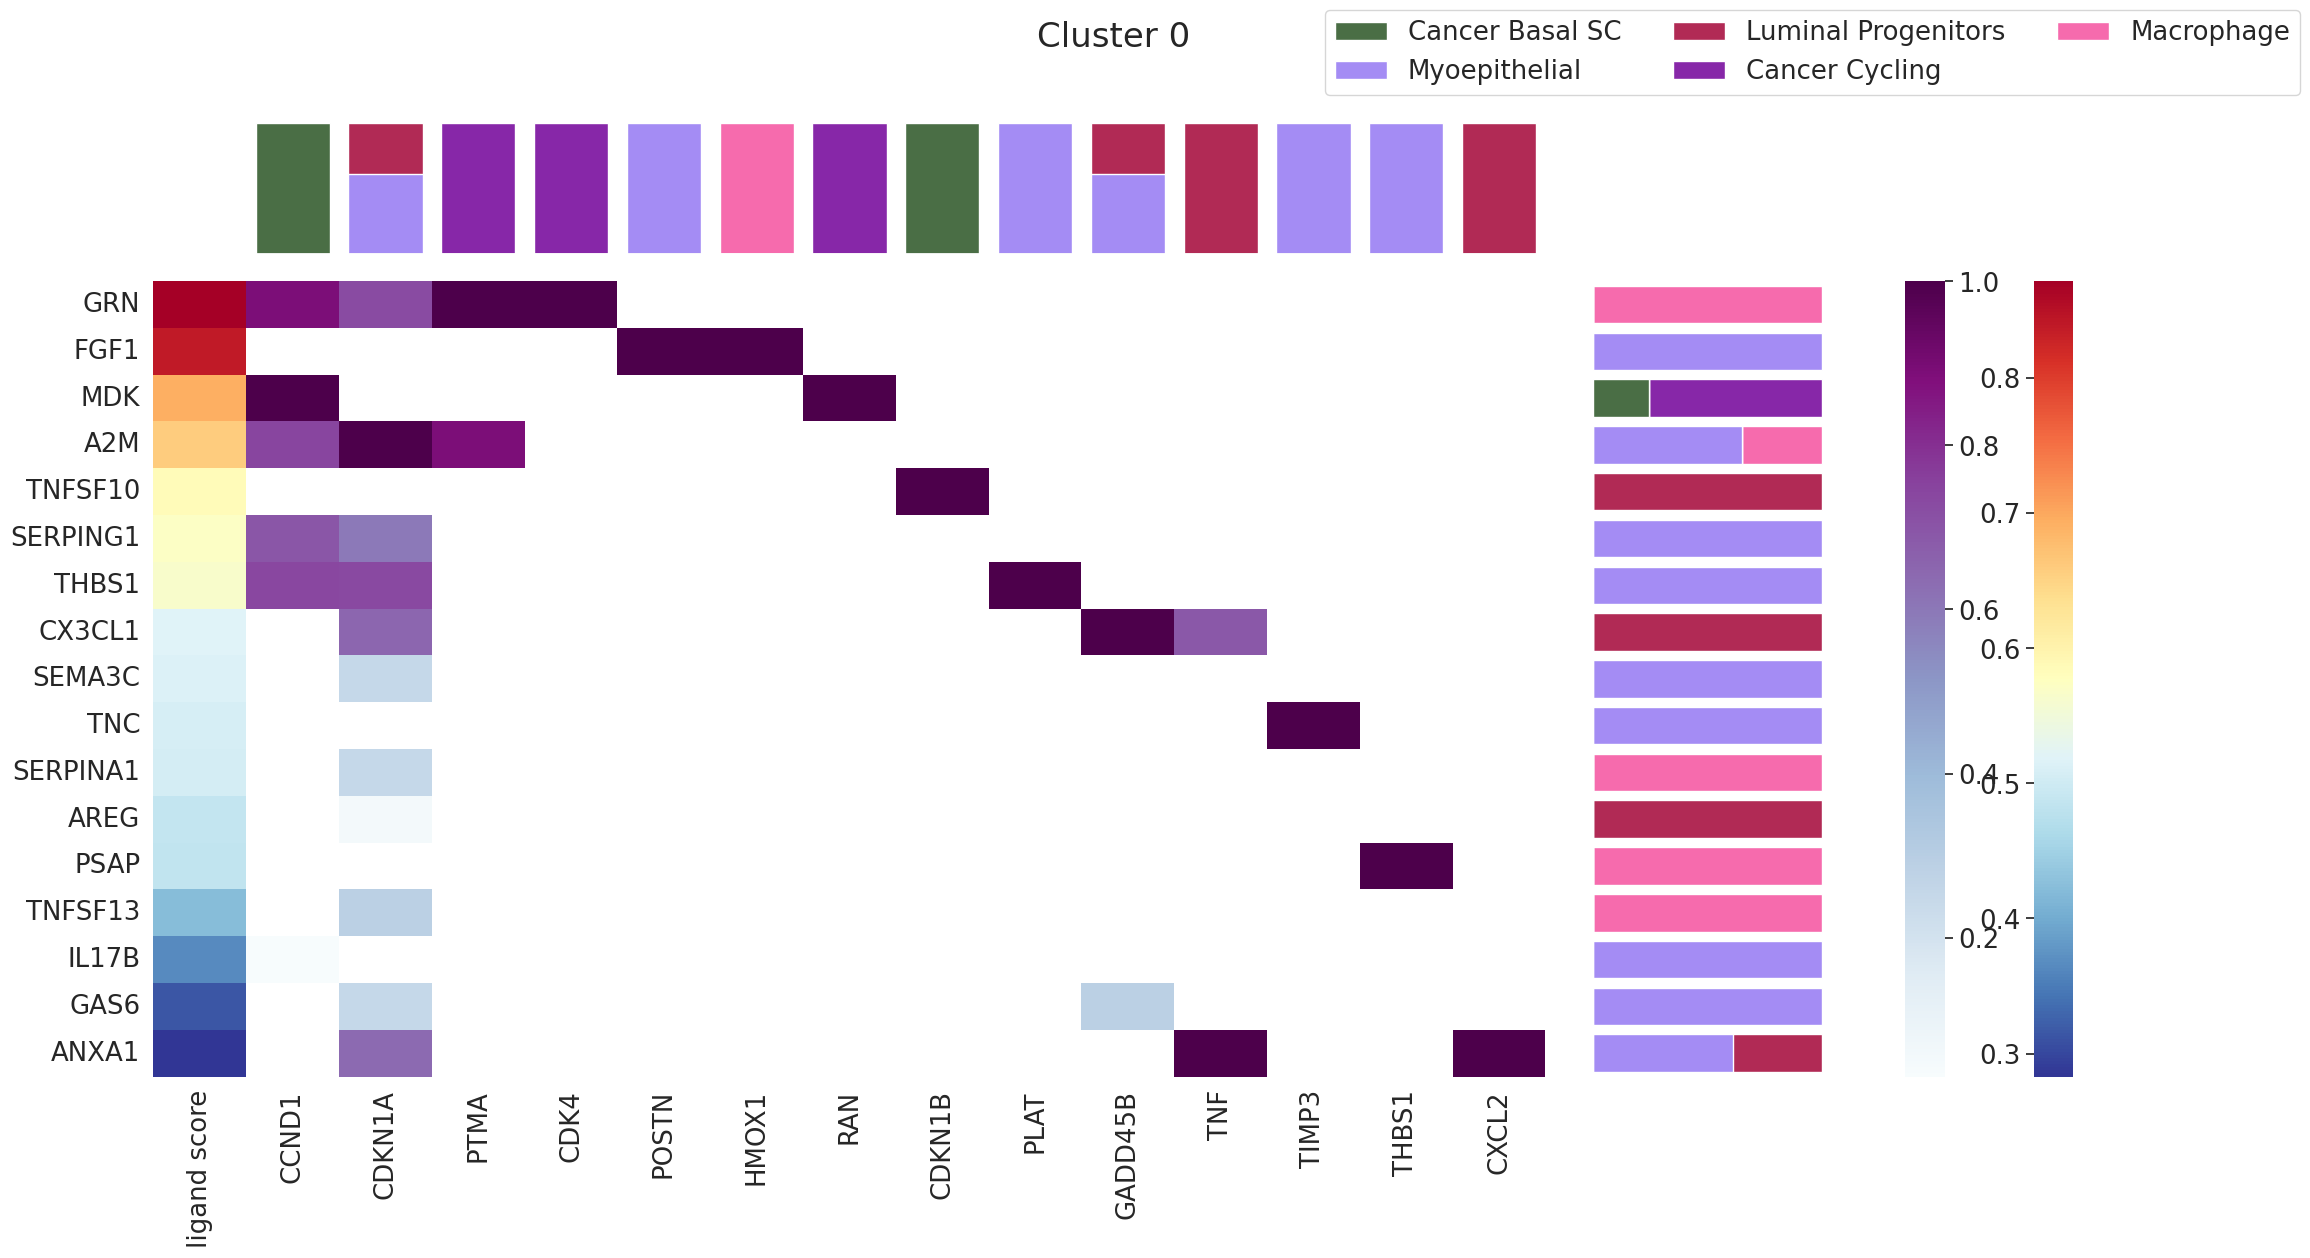

In [16]:
fig = Renoir.ligand_ranking(
    neighborhood_scores,
    celltype,
    SC,
    ligand_receptor_pairs,
    ligand_target_regulatory_potential,
    '0',                          # target domain ID
    receptor_exp=0.05,            # min receptor-expressing fraction
    markers={'top': 100},         # top-100 marker pairs as the ranking signal
    domain_celltypes=['top', 5],  # restrict to top-5 cell types in the domain
    celltype_colors=celltype_colors,
)
fig.set_size_inches(24, 12)
fig
